# Joseph's addition.

### Disclaimer to the marker.

Note my group did not ask for any of my input on the project despite my repeated asking about how I could help and barred me from making any changes to their submission of the model, and report. Not only this but removed my name from the project.

Thus this serves as a correction to their modelling, which was not well thoughtout and AI laden (in the unsupervised way).

### Central question of this addition.

I will focus on asking what is the total number of flu cases each week.

As a secondary predictions, I will use my prediction of total number of flu cases each week to try and predict the adjusted flu percentage rate and I will try to predict the number of non flu cases each week. In times of low flu cases for a particalar provider the provider will typically bother to submit the number of flu cases to the CDC.






## Data analysis:

### The data generation process

Providers collect the number of flu cases and each week submit this data to the CDC. Due to this being optional the number of providers fluctuates each week. Note if at any time we have no providers we will by definition have no flu cases being recorded.
This can be seen at various times such as during 1999 week 21 to 39. In which too flu cases were recorded by any providers to neccessitate reporting on the number of flu cases to the CDC. This does not mean that no flu cases were observed just that it was not reported.



### Structure of the data

We begin by noting that we have several count data points, thus a natural idea is to try and model these as poisson random variables with a rate parameter that fluctuates, for each of these processes. The problem is that we are unable to actaully observe the rate parameter aat each time.

Another notable thing about our data is the different age groups. The total number of recorded flu cases each week is split into several variables. That then are subdivide again in 2009 week 40 to account for a richer interpretation of the data. At this point I have decieded to manipulate that section and remerge the data so that we only consider the age groups 0-4,5-24,25-64,65. This is due to my reluctance to deal with a model that has this sort of issue.

Note: I considered doing a time series model that would split into two at that point and follow each subgroup whilst referencing the other, from that point of splitting; however I decided that this would be too complicated and thus merged them back so that we do not have any NA values.


### Periods of interest

There are some periods when the number of flu cases drops or changes significantly, and the relationship in the data changes. This happens during three periods: Covid-19 pandemic, the 2009 sars pandemic, 0 counts flu period.

**Covid**-19

During Covid-19 many people were getting a flu related illness (Covid-19) but the number of non-related flulike visits drops off significantly as people weer social distancing and lockdowns were instituted. As such the percentage of flu related visits shoots up. A trend we would expect.

**SARs**

**Zero counts**

This is a really significant problem. Our data sometimes shows zero flu counts. This is actually just a censoring. In practice it may be different for each provider and the censoring rule for any particular provider may change over time and could also be slightly random. That being said we can try and approximate it. By looking at the number of flu counts per 




## Plots of interest

Here we show the plots of interest and discuss their interpretations.

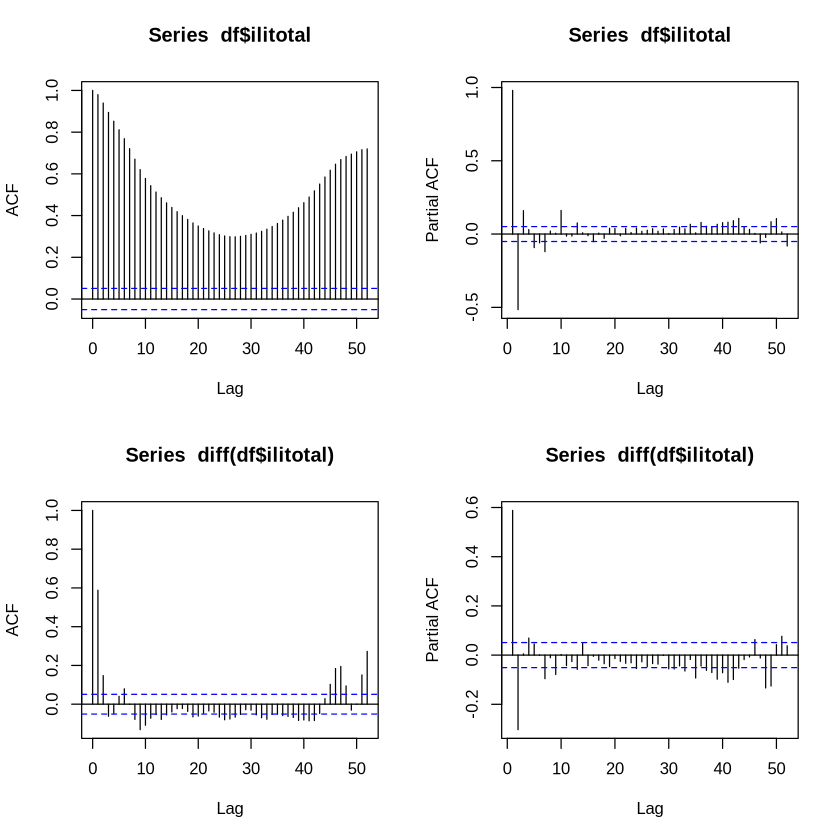

In [10]:
df <- read.csv("./data/fluview_clean/ilinet_final.csv")
par(mfrow=c(2,2))
acf(df$ilitotal,lag.max = 52)
pacf(df$ilitotal,lag.max = 52)
acf(diff(df$ilitotal),lag.max = 52)
pacf(diff(df$ilitotal),lag.max = 52)

The acf before differencing decays very slowly which indicates that differencing is required. After differencing something interesting happens, we see signinficant spikes at lag 19 and lag 33 as well as 52. Then in the PACF for the differenced series we also see this but also one at around 38. We notice that 33 = 52-19 thus the spike at lag 33 is an artifact of the spike at lag 38. 
The acf begins by having slowwly tampering off this suggests that 

## The model

The model I will use is rather simple. I will just run an multiseasonal ARIMA on each one of the subgroups in the model and then use the sum of them as the ILI_total that I would forecast. Note if I have time I will then implement a multiseasonal VARIMA to check if it does better.
To get the Non-ilitotal, I will use a VARMA / ARIMAX model using num_providers as these seem to have a very strong relationship.

Please note that while technically we cannot legally (in a statistical sense) use E(ili-total)/(E(Non-ilitotal)+E(ili-total)) = ili_unweighted percentage. We will do this and ignore Jensens to see if the value is a better predictor. 

Note ignoring Jensen's inequality is only possible due to the qnorm plots of the residuals which appear to be inverted "s"s. This means that the majority of the errors are near zero and thus the effect of Jensens inequality is minimised due to convexity.